In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio
import scipy.spatial.transform as trans
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree
import astropy.io.ascii
import random
import matplotlib

In [5]:
def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return [np.array([x[i],y[i],z[i]]) for i in range(len(a))]
    
def UnitSphereToRaDec(x,y,z):
    #x,y,z = [UScoord[i][0] for i in range(len(UScoord))],[UScoord[i][1] for i in range(len(UScoord))],[UScoord[i][2] for i in range(len(UScoord))]
    d = np.arcsin(z)
    arg = x/np.cos(d)
    def ceiling(x):
        if x > 1:
            x = 1
        if x < -1:
            x = -1
        return x
    arg = ceiling(arg)
    a = np.arccos(arg)*180/np.pi
    d = d*180/np.pi
    def negforarccos(a,y):
        if y < 0:
            a = - a + 360
        return a
    a = negforarccos(a,y)
    return [a,d] 
'''
def generateTileGrid(ralim, declim, tilecenter, gridsize):
    centerra = tilecenter[0]*np.pi/180
    centerdec = tilecenter[1]*np.pi/180
    width = (ralim[1]-ralim[0])*np.cos(centerdec)
    height = declim[1]-declim[0]
    #generate grid at 0,0
    npointsw = int(width*0.75/gridsize)
    npointsh = int(height*0.75/gridsize)
    holecenters_rarot = []
    holecenters_decrot = []
    initw = npointsw*gridsize
   r inith = npointsh*gridsize
    for i in range(2*npointsw):
        ra = -initw + i*gridsize
        for j in range(2*npointsh):
            dec = -inith + j*gridsize
            holecenters_rarot.append(ra)
            holecenters_decrot.append(dec)
    #put grid on unit sphere
    holecenters_USrot = raDecToUnitSphere(np.array(holecenters_rarot),
                                          np.array(holecenters_decrot))
    r = trans.Rotation.from_euler('yz',[-centerdec,centerra])
    #rotate grid
    holecenters_US = [r.apply(holecenters_USrot[i]) for i in range(len(holecenters_USrot))]
    #trim grid to ra, dec boundaries
    holecenters_radec = UnitSphereToRaDecPosRA(holecenters_US)
    holecenters = []
    for i in range(len(holecenters_radec)):
        if (holecenters_radec[i][0] > ralim[0]) and (holecenters_radec[i][0] < ralim[1]) \
        and (holecenters_radec[i][1] > declim[0]) and (holecenters_radec[i][1] < declim[1]):
            holecenters.append(holecenters_US[i])
    return np.array(holecenters)'''

class TileSphere:
    class Tile:
        def __init__(self,tilecenter,gridsize,tilesize,tilewidth):
            self.gridsize = gridsize
            ra = tilecenter[0]
            dec = tilecenter[1]
            decrad = dec*np.pi/180
            tile_w_holes = tilewidth + 4*gridsize/np.cos(decrad) #add padding: 2x the cell size on each side of tile
            tile_h_holes = tilesize + 4*gridsize
            tile_w_rands = tilewidth + 8*gridsize/np.cos(decrad)
            tile_h_rands = tilesize + 8*gridsize
            self.tilecenter = tilecenter
            self.ra_bounds_holes = [ra - tile_w_holes/2,ra+tile_w_holes/2]
            self.dec_bounds_holes = [dec - tile_h_holes/2,dec+tile_h_holes/2]
            self.ra_bounds_rands = [ra - tile_w_rands/2,ra+tile_w_rands/2]
            self.dec_bounds_rands = [ra - tile_w_rands/2,ra+tile_w_rands/2]
        def generateHoleGrid(self):
            centerra = self.tilecenter[0]*np.pi/180
            centerdec = self.tilecenter[1]*np.pi/180
            width = (self.ra_bounds_holes[1]-self.ra_bounds_holes[0])*np.cos(centerdec)
            height = self.dec_bounds_holes[1]-self.dec_bounds_holes[0]
            #generate grid at 0,0
            npointsw = int(width*0.75/self.gridsize)
            npointsh = int(height*0.75/self.gridsize)
            holecenters_rarot = []
            holecenters_decrot = []
            initw = npointsw*gridsize
            inith = npointsh*gridsize
            for i in range(2*npointsw):
                ra = -initw + i*gridsize
                for j in range(2*npointsh):
                    dec = -inith + j*gridsize
                    holecenters_rarot.append(ra)
                    holecenters_decrot.append(dec)
                    #put grid on unit sphere
            holecenters_USrot = raDecToUnitSphere(np.array(holecenters_rarot),
                                                  np.array(holecenters_decrot))
            r = trans.Rotation.from_euler('yz',[-centerdec,centerra])
            #rotate grid
            holecenters_US = np.array([r.apply(holecenters_USrot[i]) for i in range(len(holecenters_USrot))])
            #trim grid to ra, dec boundaries
            holecenters_radec = [UnitSphereToRaDec(holecenters_US[i][0],
                                                  holecenters_US[i][1],holecenters_US[i][2]) for i in range(len(holecenters_US))]
            def checkAngularLim(holecenter):
                return (holecenter[0] > self.ra_bounds_holes[0])&(holecenter[0] < self.ra_bounds_holes[1]) \
                &(holecenter[1] > self.dec_bounds_holes[0])&(holecenter[1] < self.dec_bounds_holes[1])
            mask = [checkAngularLim(holecenters_radec[i]) for i in range(len(holecenters_radec))]
            holecentersmasked = holecenters_US[mask]
            self.holecenters = holecentersmasked
    def __init__(self,tilesize,gridsize):
        self.gridsize = gridsize
        self.tilesize = tilesize
        #from -20 to 80 dec
        nrows = int(100 / self.tilesize)
        self.tiles = []
        for i in range(nrows):
            dec = -20 + self.tilesize*(i+0.5)
            decrad = np.pi/180*dec
            ntiles = int(np.ceil(360*np.cos(decrad)/self.tilesize))
            tilewidth = 360/ntiles
            for j in range(ntiles):
                ra = j*tilewidth
                tilecenter = [ra,dec]
                self.tiles.append(self.Tile(tilecenter,self.gridsize,self.tilesize,tilewidth))


class HoleCounter:
    def __init__(self):
        self.counter = 0

def findHoles(randtable, tile, holerad, outfilename, tilenumber):
    ralim = tile.ra_bounds_holes
    declim = tile.dec_bounds_holes
    #print("checking for galaxies in tile")
    randscut = randtable[(randtable['RA'] > ralim[0])&(randtable['RA'] < ralim[1]) &\
        (randtable['DEC'] > declim[0])&(randtable['DEC'] < declim[1])]
    if len(randscut) > 0:
        #print("searching for holes in tile")
        tile.generateHoleGrid()
        randsCartesian = raDecToUnitSphere(randscut['RA'],randscut['DEC'])
        randsphere = cKDTree(randsCartesian)
        rad = holerad*np.pi/180
        holetree = cKDTree(tile.holecenters)
        neighbors = holetree.query_ball_tree(randsphere,rad)
        holemask = [(len(n) < 1) for n in neighbors]    
        holes = tile.holecenters[holemask]
        holetable = Table()
        holetable['x'] = [holes[i][0] for i in range(len(holes))]
        holetable['y'] = [holes[i][1] for i in range(len(holes))]
        holetable['z'] = [holes[i][2] for i in range(len(holes))]
        astropy.io.ascii.write(holetable, 'datafiles/'+outfilename+\
                               '_tile'+str(tilenumber.counter)+'_holes.csv', overwrite=True,format='csv')
        if tilenumber.counter % 100 == 0: print("saved holes for tile "+str(tilenumber.counter))
        tilenumber.counter += 1
        
def searchSkyForHoles(tilesize, gridsize, holerad, randtable, outfilename):
    print("generating tiles")
    tilesphere = TileSphere(tilesize,gridsize)
    tilenumber = HoleCounter()
    for tile in tilesphere.tiles:
        findHoles(randtable,tile,holerad,outfilename,tilenumber)
    print("total tiles: "+str(tilenumber.counter))
    
def Poisson(N, k):
    #nexp is the expectation CiC
    #k is the measured CiC whose probability you're querying
    if k == 0:
        return np.exp(-N)
    else:
        product = 1
        for i in np.arange(1,k+1):
            product = product * N / i
        p = product*np.exp(-N)
        return p

In [6]:
#Load Aurelio's Randoms
'''
randir = "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/ELG/ran0/"
randtables = []
for i in np.arange(0,18):
    #ranfile = randir+"random"+str(i)+"_elg1_Y1_fiducial.fits"
    ranfile = randir+"random"+str(i)+"_elg0_Y1_fiducial.fits"
    sp = Table(fitsio.read(ranfile))
    randtables.append(sp)
randtable = vstack(randtables)
'''

#Load Uchuu Randoms
randtables = []
randir = "/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Y3-v2.0/0000/"
for i in np.arange(4):
    ranfile = randir + "Uchuu-SHAM_LRG_Y3-v2.0_0000_"+str(i)+"_clustering.ran.fits"
    sp = Table(fitsio.read(ranfile))
    randtables.append(sp)
randtable = vstack(randtables)


OSError: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Y3-v2.0/0000/Uchuu-SHAM_LRG_Y3-v2.0_
0000_0_clustering.ran.fits


In [7]:
randir = "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/LRG/ran0/"
randtables = []
for i in np.arange(0,18):
    #ranfile = randir+"random"+str(i)+"_elg1_Y1_fiducial.fits"
    ranfile = randir+"random"+str(i)+"_lrg0_Y1_fiducial.fits"
    sp = Table(fitsio.read(ranfile))
    randtables.append(sp)
lrgrandtable = vstack(randtables)

In [11]:
#load SV3 randoms
randir = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/"
randtables = []
for i in range(18):
    ranfileN = randir + "ELG_N_"+str(i)+"_clustering.ran.fits"
    ranfileS = randir + "ELG_S_"+str(i)+"_clustering.ran.fits"
    spN = Table(fitsio.read(ranfileN))
    spS = Table(fitsio.read(ranfileS))
    randtables.append(spN)
    randtables.append(spS)
elgSV3randtable = vstack(randtables)


In [9]:
#Load randoms with holes
randtables = []
for i in range(18):
    ranfile = "randoms/ranEbits"+str(i)+".csv"
    sp = Table.read(ranfile)
    randtables.append(sp)
holeErands = vstack(randtables)

FileNotFoundError: [Errno 2] No such file or directory: 'randoms/ranEbits0.csv'

In [ ]:
y1dir = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/'
randtables = []
for i in range(18):
    ranfile = y1dir + "ELG_LOPnotqso_"+str(i)+"_full.ran.fits"
    sp = Table(fitsio.read(ranfile))
    sp2 = Table([sp['RA'],sp['DEC']]) #to reduce memory required
    randtables.append(sp2)
elgY1randtable = vstack(randtables)

In [ ]:
#load SV3 randoms
randir = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/"
randtables = []
for i in range(18):
    ranfileN = randir + "LRG_N_"+str(i)+"_clustering.ran.fits"
    ranfileS = randir + "LRG_S_"+str(i)+"_clustering.ran.fits"
    spN = Table(fitsio.read(ranfileN))
    spS = Table(fitsio.read(ranfileS))
    randtables.append(spN)
    randtables.append(spS)
lrgSV3randtable = vstack(randtables)


In [ ]:
'''
plan: mess around to find a spot with some holes
check average number of random galaxies per unit area in Aurelio's mocks
write function to find probability of getting 0 in a circle of some radius based on random density
make grid density 1/2 of holecenter radius

Check algorithm on small patch of sky, maybe a patch close to 0,0 and a patch not close to 0,0


'''

In [12]:
ra1 = 150.1
dec1 = 2.182
'''
ra1 = 160
dec1 = 0'''
sidelength = 0.5
stepsize = 0.01
nsteps = int(sidelength/stepsize)
randtable=elgSV3randtable
randtablecut = randtable[(randtable['RA'] > ra1 - nsteps*stepsize) & (randtable['RA'] < ra1 + nsteps*stepsize) \
&(randtable['DEC'] > dec1 - nsteps*stepsize)&(randtable['DEC'] < dec1 + nsteps*stepsize)]

print(len(randtablecut))


42712


Text(0.5, 1.0, 'Holes in ELG Random Catalogs (SV3)')

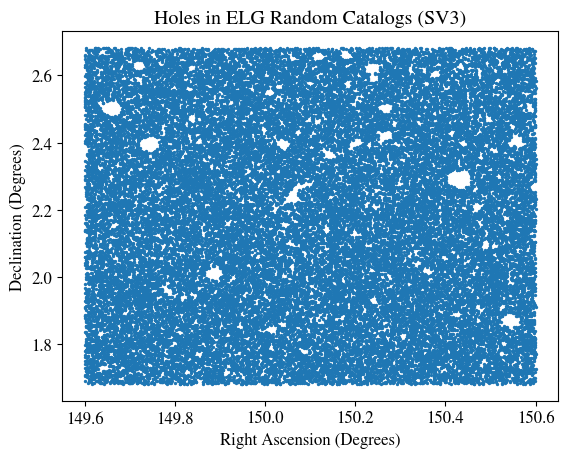

In [20]:
'''hist1,binsy,binsx = np.histogram2d(randtablecut['DEC'],randtablecut['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1,vmax=3)
cbar = plt.colorbar(pc)'''

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12

plt.scatter(randtablecut['RA'],randtablecut['DEC'],s=2)
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.title("Holes in ELG Random Catalogs (SV3)")

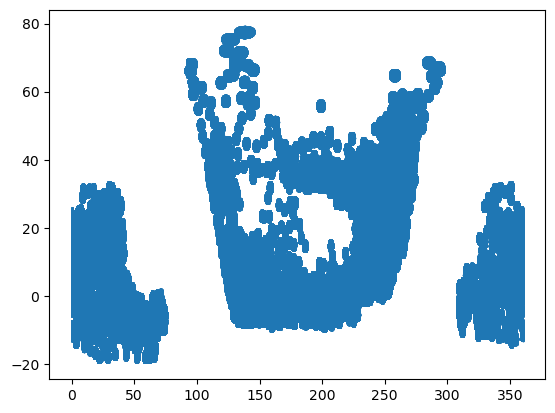

In [105]:
plt.scatter(sp['RA'],sp['DEC'],s=0.2)

In [95]:
#test out algorithm on small patch of sky
tilesize = 2
gridsize = 0.008
holerad = 0.008
#randtable = randtablecut
searchSkyForHoles(tilesize, gridsize, holerad, randtablecut, "smallpatch")

generating tiles
saved holes for one tile
saved holes for one tile
saved holes for one tile
total tiles: 3


In [85]:
#Load Aurelio's Randoms

file = "datafiles/smallpatch_tile2_holes.csv"
sp = Table.read(file,format='csv')
    

holesradec = UnitSphereToRaDecPosRA([[coord['x'],coord['y'],coord['z']] for coord in sp])

(39.4, 40.6)

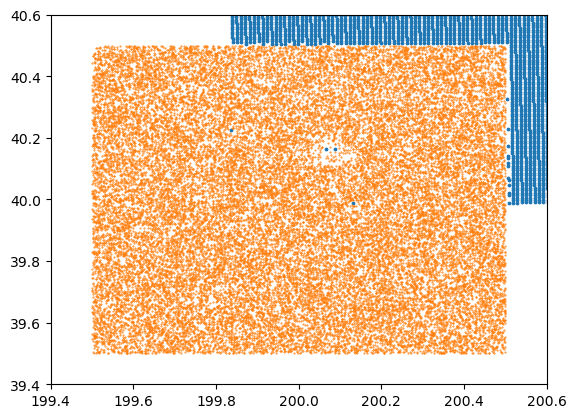

In [86]:
ras = [holesradec[i][0] for i in range(len(holesradec))]
decs = [holesradec[i][1] for i in range(len(holesradec))]
plt.scatter(ras,decs,s=3)
plt.scatter(randtablecut['RA'],randtablecut['DEC'],s=0.2)
plt.xlim(ra1-0.6,ra1+0.6)
plt.ylim(dec1-0.6,dec1+0.6)

In [4]:
tilesize = 10
gridsize = 0.1
tilecenters, rabounds, decbounds = generateTiles(tilesize,gridsize)
holecenters = [generateTileGrid(rabounds[i], decbounds[i], tilecenters[i], gridsize) for i in range(len(tilecenters))]

(-75.0, -50.0)

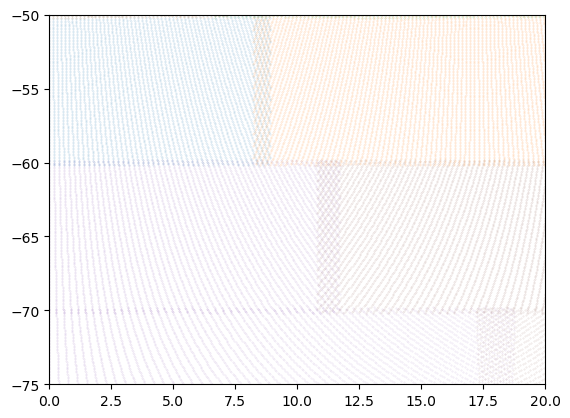

In [5]:
for i in range(len(tilecenters)):
    radec = UnitSphereToRaDec(holecenters[i])
    ra = [radec[j][0] for j in range(len(radec))]
    dec = [radec[j][1] for j in range(len(radec))]
    plt.scatter(ra,dec,alpha=0.2,s=0.1)#,alpha=0.2,s=0.5)
    
plt.xlim(0,20)
plt.ylim(-75,-50)

0.001167998298428339


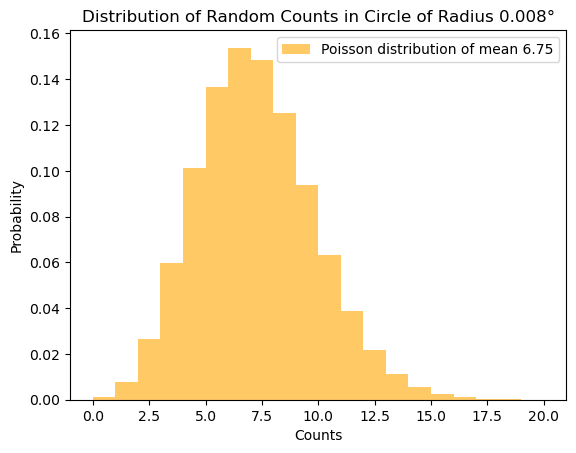

In [7]:
#plot Poisson distribution
N = len(randtablecut)/(1**2)*(np.pi*0.008**2)
ns = np.arange(0,20)
ps = [Poisson(N,n) for n in ns]
plt.figure()
plt.bar(ns,ps,color='orange',align='edge',width=1,alpha=0.6,label='Poisson distribution of mean '+str(np.round(N,2)))
plt.legend()
plt.title("Distribution of Random Counts in Circle of Radius 0.008°")
plt.xlabel("Counts")
plt.ylabel("Probability")
print(ps[0])

In [4]:
#ra1 = 11

randtablecut2 = randtable[(randtable['RA'] > 150) & (randtable['RA'] < 200) \
&(randtable['DEC'] > -5.25)&(randtable['DEC'] < 3.75)]

In [ ]:
#try on whole random catalog
outfilename = 'CiCRandomsAllSky'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, randtable, outfilename)

In [5]:
#try on whole random catalog
outfilename = 'CiCRandomsAllSkyLRG'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, lrgrandtable, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
saved holes for tile 200
saved holes for tile 300
saved holes for tile 400
saved holes for tile 500
saved holes for tile 600
saved holes for tile 700
saved holes for tile 800
saved holes for tile 900
saved holes for tile 1000
saved holes for tile 1100
saved holes for tile 1200
saved holes for tile 1300
saved holes for tile 1400
saved holes for tile 1500
saved holes for tile 1600
saved holes for tile 1700
saved holes for tile 1800
saved holes for tile 1900
saved holes for tile 2000
saved holes for tile 2100
saved holes for tile 2200
saved holes for tile 2300
saved holes for tile 2400
saved holes for tile 2500
saved holes for tile 2600
saved holes for tile 2700
saved holes for tile 2800
saved holes for tile 2900
saved holes for tile 3000
saved holes for tile 3100
total tiles: 3165


In [4]:
#try on whole random catalog
outfilename = 'Holes_ELG_SV3'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, elgSV3randtable, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
total tiles: 117


In [6]:
#try on whole random catalog
outfilename = 'Holes_LRG_SV3'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, lrgSV3randtable, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
total tiles: 119


In [ ]:
#try on whole random catalog
outfilename = 'Holes_ELG_Y1'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, elgY1randtable, outfilename)

In [109]:
#check the results
holelist = []
for i in range(3165):
    holeselg = Table.read("datafiles/CiCRandomsAllSky_tile"+str(i)+"_holes.csv",format="csv")
    holelist.append(holeselg)
    #if (i % 100 == 0): print("read data file "+str(i))
holetable = vstack(holelist)

read data file 0
read data file 100
read data file 200
read data file 300
read data file 400
read data file 500
read data file 600
read data file 700
read data file 800
read data file 900
read data file 1000
read data file 1100
read data file 1200
read data file 1300
read data file 1400
read data file 1500
read data file 1600
read data file 1700
read data file 1800
read data file 1900
read data file 2000
read data file 2100
read data file 2200
read data file 2300
read data file 2400
read data file 2500
read data file 2600
read data file 2700
read data file 2800
read data file 2900
read data file 3000
read data file 3100


In [140]:
holescut = holetable[(holetable['y']>0)&(holetable['y']<0.1)&(holetable['z']<0.1)\
        &(holetable['z']>0)]
holesradec = [UnitSphereToRaDec(coord['x'],coord['y'],coord['z']) for coord in holescut]
ras = [holesradec[i][0] for i in range(len(holesradec))]
decs = [holesradec[i][1] for i in range(len(holesradec))]

In [145]:
randtablecut = randtable[(randtable['RA'] > 4)&(randtable['RA'] < 5) &\
        (randtable['DEC'] > 1)&(randtable['DEC'] < 2)]

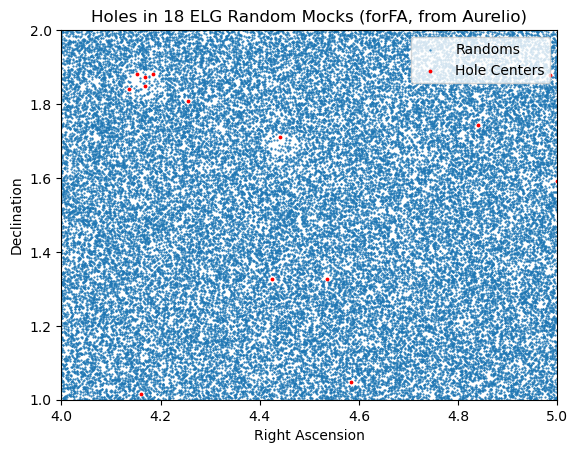

In [155]:
plt.figure()
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Holes in 18 ELG Random Mocks (forFA, from Aurelio)")
plt.scatter(randtablecut['RA'],randtablecut['DEC'],s=0.3,label = 'Randoms')
plt.scatter(ras,decs,s=3,color='red',label= 'Hole Centers')
plt.xlim(4,5)
plt.ylim(1,2)
plt.legend(loc='upper right')

In [148]:
print(len(holetable))

49516242


In [19]:
#poke around with LSS randoms
table1 = []
for i in np.arange(18):
    eNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_N_'+str(i)+'_clustering.ran.fits'
    eSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_S_'+str(i)+'_clustering.ran.fits'
    lNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_N_'+str(i)+'_clustering.ran.fits'
    lSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_S_'+str(i)+'_clustering.ran.fits'
    speN = Table(fitsio.read(eNfile))
    speS = Table(fitsio.read(eSfile))
    splN = Table(fitsio.read(lNfile))
    splS = Table(fitsio.read(lSfile))
    table1.append(speN)
    table1.append(speS)
    #table1.append(splN)
    #table1.append(splS)
randtable = vstack(table1)

print(len(table1[0]))
print(len(randtable))    

210032
7579706


In [21]:
randoms1 = randtable
ra1 = 150.1
dec1 = 2.182
cut2 = randoms1[(randoms1['RA'] > ra1-0.5)&(randoms1['RA']<ra1+0.5)&(randoms1['DEC']>dec1-0.5)&(randoms1['DEC']<dec1+0.5)]

In [96]:
#test out algorithm on small patch of sky
tilesize = 2
gridsize = 0.008
holerad = 0.008
#randtable = randtablecut
holes = searchSkyForHoles(tilesize, gridsize, holerad, cut2, "attempt2cut")

NameError: name 'cut2' is not defined

In [ ]:
holesradec = UnitSphereToRaDecPosRA(holes)
ras = [holesradec[i][0] for i in range(len(holesradec))]
decs = [holesradec[i][1] for i in range(len(holesradec))]
plt.scatter(ras,decs,s=3)
plt.scatter(cut2['RA'],cut2['DEC'],s=0.2)
plt.xlim(ra1-0.6,ra1+0.6)
plt.ylim(dec1-0.6,dec1+0.6)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Holes Found in SV3 LSS Catalog")

In [5]:
#rands with ebits applied
tilesize = 2
gridsize = 0.008
holerad = 0.008
filename = "holesEbits"
holes = searchSkyForHoles(tilesize, gridsize, holerad, holeErands, filename)

generating tiles
saved holes for tile 0
saved holes for tile 100
saved holes for tile 200
total tiles: 240


In [5]:
#forFA rands
randir = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock1/"
elgtable = []
lrgtable = []
for i in np.arange(18):
    efile = randir+'ELG_LOP_complete_'+str(i)+'_clustering.ran.fits'
    lfile = randir+'LRG_complete_'+str(i)+'_clustering.ran.fits'
    spe = Table(fitsio.read(efile))
    spe2 = Table([spe['RA'],spe['DEC']]) 
    spl = Table(fitsio.read(lfile))
    spl2 = Table([spl['RA'],spl['DEC']])
    #elgcut = spe[(spe['RA'] > ra1-nsteps*stepsize)&(spe['RA']<ra1+nsteps*stepsize)&(spe['DEC']>dec1-nsteps*stepsize)&(spe['DEC']<dec1+nsteps*stepsize)]
    #lrgcut = spl[(spl['RA'] > ra1-nsteps*stepsize)&(spl['RA']<ra1+nsteps*stepsize)&(spl['DEC']>dec1-nsteps*stepsize)&(spl['DEC']<dec1+nsteps*stepsize)]
    elgtable.append(spe2)
    lrgtable.append(spl2)
    #table1.append(splN)
    #table1.append(splS)
randelg = vstack(elgtable)
randlrg = vstack(lrgtable)

In [6]:
ralim = [130,223]
declim  = [-5.25,3.75]
randelg = randelg[(randelg['RA'] > ralim[0])&(randelg['RA'] < ralim[1])&\
        (randelg['DEC'] > declim[0])& (randelg['DEC'] < declim[1])]
randlrg = randlrg[(randlrg['RA'] > ralim[0])&(randlrg['RA'] < ralim[1])&\
        (randlrg['DEC'] > declim[0])& (randlrg['DEC'] < declim[1])]

In [7]:
outfilename = 'forFAelg'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, randelg, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
saved holes for tile 200
total tiles: 240


In [8]:
outfilename = 'forFAlrg'
tilesize = 2
gridsize = 0.008
holerad = 0.008
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, randlrg, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
saved holes for tile 200
total tiles: 240


In [14]:
#Uchuu SV3 rands
randir = "/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/"
elgtable = []
for i in np.arange(18):
    eNfile = randir+'ELG_Uchuu/ELG_N_'+str(i)+"_uchuu.ran.fits"
    eSfile = randir+'ELG_Uchuu/ELG_S_'+str(i)+"_uchuu.ran.fits"
    speN = Table(fitsio.read(eNfile))
    speN2 = Table([speN['RA'],speN['DEC']]) 
    speS = Table(fitsio.read(eSfile))
    speS2 = Table([speS['RA'],speS['DEC']])
    #elgcut = spe[(spe['RA'] > ra1-nsteps*stepsize)&(spe['RA']<ra1+nsteps*stepsize)&(spe['DEC']>dec1-nsteps*stepsize)&(spe['DEC']<dec1+nsteps*stepsize)]
    #lrgcut = spl[(spl['RA'] > ra1-nsteps*stepsize)&(spl['RA']<ra1+nsteps*stepsize)&(spl['DEC']>dec1-nsteps*stepsize)&(spl['DEC']<dec1+nsteps*stepsize)]
    elgtable.append(speN2)
    elgtable.append(speS2)
    #table1.append(splN)
    #table1.append(splS)
randelg = vstack(elgtable)

In [12]:
lrgfileS = randir + "LRG_main_Uchuu/LRG_main_S_uchuu.ran.fits"
lrgfileN = randir + "LRG_main_Uchuu/LRG_main_N_uchuu.ran.fits"
lrgrandS = Table(fitsio.read(lrgfileS))
lrgrandN = Table(fitsio.read(lrgfileN))
randlrg = vstack([lrgrandS,lrgrandN])
#randlrg = randlrg[[(random.random() < 0.263) for i in range(len(randlrg))]]

In [15]:
print(len(randelg),len(randlrg))

83792571 5100477


In [10]:
#outfilename = 'Uchuu_SV3_lrg'
tilesize = 2
gridsize = 0.008
holerad = 0.008
#allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, randlrg, outfilename)
outfilename = 'Uchuu_SV3_elg'
allskyholes = searchSkyForHoles(tilesize, gridsize, holerad, randlrg, outfilename)

generating tiles
saved holes for tile 0
saved holes for tile 100
total tiles: 119


In [19]:
83792571/318705118

0.26291567429425466

In [16]:
83792571/18

4655142.833333333

In [18]:
5100477/40

127511.925

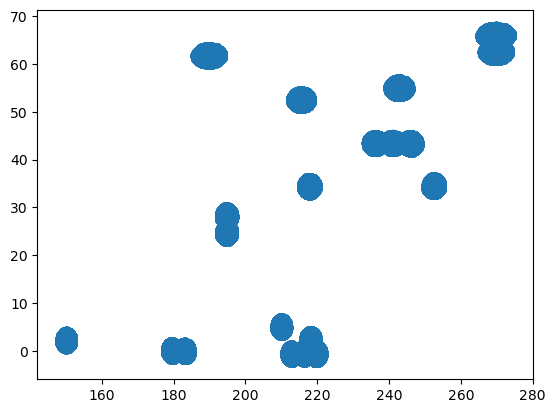

In [19]:
lrgcut = 
plt.scatter(randlrg['RA'],randlrg['DEC'])